# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [4]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),          # flat vector: 3072
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),             # Task 1: added extra Dense layer
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),             # Task 1: increased layout depth
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name="ANN")

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
ann_history = ann_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.0999 - loss: 10.6121 - val_accuracy: 0.1002 - val_loss: 2.3028
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.0981 - loss: 2.3037 - val_accuracy: 0.1001 - val_loss: 2.3026
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.0994 - loss: 2.3032 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.0995 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.0980 - loss: 2.3029 - val_accuracy: 0.0999 - val_loss: 2.3027
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.1006 - loss: 2.3028 - val_accuracy: 0.0999 - val_loss: 2.3027
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.0985 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.0968 - loss: 2.3028 -

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2 — Task 2: scaled filters 32→64
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3 — Task 2: scaled filters 64→128
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name="CNN")

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,818 (2.55 MB)

 Trainable params: 667,178 (2.55 MB)

 Non-trainable params: 640 (2.50 KB)

In [8]:
cnn_history = cnn_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 206s 260ms/step - accuracy: 0.3968 - loss: 1.6850 - val_accuracy: 0.5331 - val_loss: 1.3074
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 259ms/step - accuracy: 0.5622 - loss: 1.2374 - val_accuracy: 0.5879 - val_loss: 1.2094
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 262s 259ms/step - accuracy: 0.6288 - loss: 1.0641 - val_accuracy: 0.6535 - val_loss: 0.9834
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 259ms/step - accuracy: 0.6692 - loss: 0.9564 - val_accuracy: 0.6652 - val_loss: 0.9722
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 260ms/step - accuracy: 0.6999 - loss: 0.8608 - val_accuracy: 0.7347 - val_loss: 0.7523
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 258ms/step - accuracy: 0.7186 - loss: 0.8069 - val_accuracy: 0.7546 - val_loss: 0.7079
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 259ms/step - accuracy: 0.7363 - loss: 0.7566 - val_accuracy: 0.7628 - val_loss: 0.7064
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 258ms/step - accuracy: 0.7544 -

## 📈 Compare Learning Curves

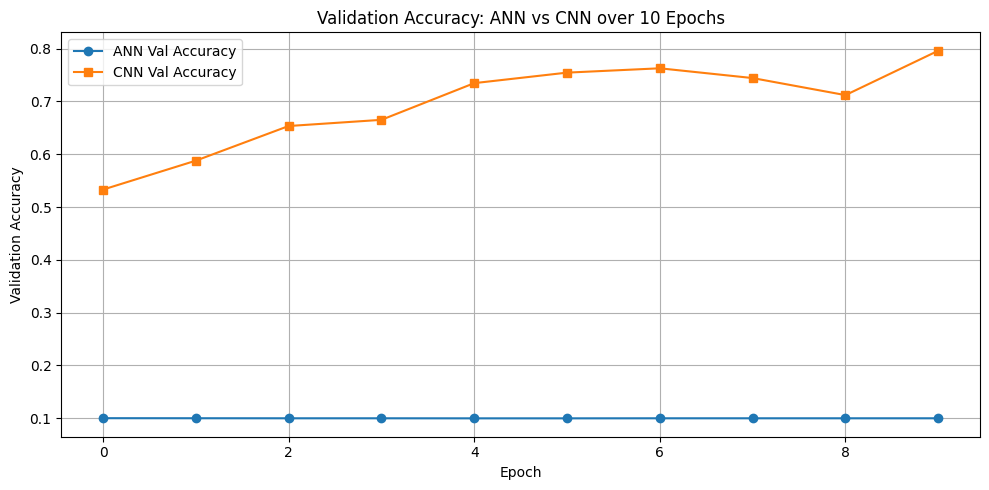

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Accuracy', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy', marker='s')
plt.title('Validation Accuracy: ANN vs CNN over 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ann_vs_cnn_accuracy.png', dpi=150)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
# Task 3: Data Augmentation layers
from tensorflow.keras.callbacks import EarlyStopping
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="Augmentation")

aug_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name="Augmented_CNN")

aug_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Task 4: EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=4,
                            restore_best_weights=True, verbose=1)

# Task 5: Train for 20 epochs with EarlyStopping
aug_history = aug_model.fit(
    x_train, y_train,
    epochs=20,                          # Task 5: 20 epochs
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],             # Task 4: EarlyStopping
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 129ms/step - accuracy: 0.3347 - loss: 1.8479 - val_accuracy: 0.4289 - val_loss: 1.6826
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 127ms/step - accuracy: 0.4338 - loss: 1.5664 - val_accuracy: 0.4680 - val_loss: 1.5281
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 126ms/step - accuracy: 0.4743 - loss: 1.4567 - val_accuracy: 0.5568 - val_loss: 1.2574
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.5063 - loss: 1.3850 - val_accuracy: 0.6123 - val_loss: 1.0800
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.5298 - loss: 1.3222 - val_accuracy: 0.5047 - val_loss: 1.4950
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.5498 - loss: 1.2722 - val_accuracy: 0.5955 - val_loss: 1.1722
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.5665 - loss: 1.2280 - val_accuracy: 0.5578 - val_loss: 1.2811
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 126ms/step - accuracy: 0.5780 - loss

# 📊 Final Comparison Table

In [13]:
ann_test_acc  = ann_model.evaluate(x_test, y_test, verbose=0)[1]
cnn_test_acc  = cnn_model.evaluate(x_test, y_test, verbose=0)[1]
aug_test_acc  = aug_model.evaluate(x_test, y_test, verbose=0)[1]

results_df = pd.DataFrame({
    'Model':         ['ANN (Dense+Dropout)', 'CNN (Conv2D+BN)', 'Augmented CNN (20 ep)'],
    'Test Accuracy': [f"{ann_test_acc*100:.2f}%",
                      f"{cnn_test_acc*100:.2f}%",
                      f"{aug_test_acc*100:.2f}%"],
    'Epochs Trained':[10, 10, f"≤20 (EarlyStopping)"],
    'Key Features':  ['Flatten→Dense→Dropout',
                      'Conv2D→BN→MaxPool→Dense',
                      'Augment+Conv→BN→EarlyStopping']
})

print(results_df.to_string(index=False))
results_df

                Model Test Accuracy      Epochs Trained                  Key Features
  ANN (Dense+Dropout)        10.00%                  10         Flatten→Dense→Dropout
      CNN (Conv2D+BN)        79.61%                  10       Conv2D→BN→MaxPool→Dense
Augmented CNN (20 ep)        71.75% ≤20 (EarlyStopping) Augment+Conv→BN→EarlyStopping


,Model,Test Accuracy,Epochs Trained,Key Features
0,ANN (Dense+Dropout),10.00%,10,Flatten→Dense→Dropout
1,CNN (Conv2D+BN),79.61%,10,Conv2D→BN→MaxPool→Dense
2,Augmented CNN (20 ep),71.75%,≤20 (EarlyStopping),Augment+Conv→BN→EarlyStopping


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**